
# Simulation diagnostic: SciPy minimize vs torch Vecchia autograd

Goal: use the local July simulation data for one day (8 hours) and fit each hour twice with the **same anisotropic covariance parameterization**:

1. **SciPy full GP likelihood**: exact dense anisotropic Matern likelihood with GLS-profiled mean, optimized by `scipy.optimize.minimize` / L-BFGS-B on the same `phi1, phi2, phi3, nugget` parameterization.
2. **Existing torch Vecchia autograd**: production-style group/cluster Vecchia 4x4 with 2 conditioning blocks, using anisotropic microergodic parameters and autograd L-BFGS.

Both methods estimate

`sigmasq, range_lat, range_lon, nugget` (reported scale; torch optimizes the equivalent `phi1, phi2, phi3, nugget` scale)

with `smooth` fixed to the simulation truth. Both optimizers use the same raw parameterization, so the comparison targets the likelihood/optimizer implementation rather than a coordinate-system difference.

Default setting uses `smooth0p5`, July 1, 2024, and `N_FIT=800` max-min selected finite points per hour so dense full likelihood remains feasible on a laptop. Increase `N_FIT` only if the dense SciPy part is not too slow.


In [1]:

from pathlib import Path
import json
import math
import os
import pickle
import re
import sys
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from scipy.linalg import cho_factor, cho_solve
from scipy.optimize import minimize
from scipy.spatial.distance import cdist
from scipy.special import gamma, kv

REPO = Path('/Users/joonwonlee/Documents/GEMS_TCO-1')
SRC = REPO / 'src'
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

try:
    import torch
    from GEMS_TCO.kernels_space_iso_cluster_052426 import ClusterSpaceVecchiaFit
    from GEMS_TCO.kernels_space_base_engine_052126 import _MeanDesignMixin, _build_matern_spline_coeffs

    class ClusterSpaceAnisoMicroergodicTrendVecchiaFit(_MeanDesignMixin, ClusterSpaceVecchiaFit):
        # Production-style anisotropic group Vecchia. Optimized raw params are
        # log(phi1), log(phi2), log(phi3), log(nugget), with
        # phi2 = 1/range_lon, phi3 = (range_lon/range_lat)^2,
        # sigmasq = phi1/phi2.
        def __init__(self, *args, mean_design: str = 'lat', **kwargs):
            requested_smooth = float(kwargs.get('smooth', args[0] if args else 0.5))
            if requested_smooth <= 0.0:
                raise ValueError(f'smooth must be positive, got {requested_smooth}')
            # Base class only accepts 0.5/1.5; pass 0.5 and then restore arbitrary smooth.
            if 'smooth' in kwargs:
                kwargs = dict(kwargs)
                kwargs['smooth'] = 0.5
                super().__init__(*args, **kwargs)
            else:
                args = (0.5,) + tuple(args[1:]) if args else args
                super().__init__(*args, **kwargs)
            self.smooth = requested_smooth
            self._matern_spline_tensors = {}
            self._init_mean_design(mean_design)

        def _get_matern_spline_tensors(self, smooth: float):
            key = round(float(smooth), 8)
            if key in self._matern_spline_tensors:
                return self._matern_spline_tensors[key]
            coeffs = _build_matern_spline_coeffs(float(smooth))
            tensors = {
                name: torch.tensor(arr, dtype=torch.float64, device=self.device)
                for name, arr in coeffs.items()
                if name != 'r_max'
            }
            tensors['r_max'] = float(coeffs['r_max'])
            self._matern_spline_tensors[key] = tensors
            return tensors

        def _matern_corr(self, dist: torch.Tensor) -> torch.Tensor:
            if self.smooth == 0.5:
                return torch.exp(-dist)
            if self.smooth == 1.5:
                return (1.0 + dist) * torch.exp(-dist)
            sp = self._get_matern_spline_tensors(self.smooth)
            r_c = dist.clamp(0.0, sp['r_max'])
            orig_shape = r_c.shape
            r_flat = r_c.reshape(-1)
            idx = torch.searchsorted(sp['knots'], r_flat, right=True) - 1
            idx = idx.clamp(0, sp['knots'].numel() - 2)
            dx = r_flat - sp['knots'][idx]
            vals = sp['a'][idx] + dx * (sp['b'][idx] + dx * (sp['c'][idx] + dx * sp['d'][idx]))
            return vals.reshape(orig_shape).clamp_min(0.0)

        def _raw_params(self, params: torch.Tensor):
            phi1 = torch.exp(params[0])
            phi2 = torch.exp(params[1])
            phi3 = torch.exp(params[2])
            sigmasq = phi1 / phi2
            range_lon = 1.0 / phi2
            range_lat = 1.0 / (phi2 * torch.sqrt(phi3).clamp_min(1e-12))
            nugget = torch.exp(params[3])
            return sigmasq, range_lat, range_lon, nugget

        def _cov_from_deltas(self, d_lat, d_lon, params: torch.Tensor):
            sigmasq, range_lat, range_lon, _ = self._raw_params(params)
            dist = torch.sqrt(
                d_lat.new_tensor(1e-8)
                + (d_lat / range_lat.clamp_min(1e-12)).pow(2)
                + (d_lon / range_lon.clamp_min(1e-12)).pow(2)
            )
            return sigmasq * self._matern_corr(dist)

        def _convert_params(self, raw):
            phi1 = float(np.exp(raw[0]))
            phi2 = float(np.exp(raw[1]))
            phi3 = float(np.exp(raw[2]))
            range_lon = 1.0 / phi2
            range_lat = 1.0 / (phi2 * np.sqrt(phi3))
            sigmasq = phi1 / phi2
            return {
                'sigmasq': sigmasq,
                'range_lat': range_lat,
                'range_lon': range_lon,
                'nugget': float(np.exp(raw[3])),
                'phi1': phi1,
                'phi2': phi2,
                'phi3': phi3,
            }

    TORCH_AVAILABLE = True
    TORCH_IMPORT_ERROR = None
except Exception as e:
    TORCH_AVAILABLE = False
    TORCH_IMPORT_ERROR = repr(e)

try:
    from GEMS_TCO import orderings
    ORDERINGS_AVAILABLE = True
    ORDERINGS_IMPORT_ERROR = None
except Exception as e:
    ORDERINGS_AVAILABLE = False
    ORDERINGS_IMPORT_ERROR = repr(e)

print('torch available:', TORCH_AVAILABLE, TORCH_IMPORT_ERROR or '')
print('orderings available:', ORDERINGS_AVAILABLE, ORDERINGS_IMPORT_ERROR or '')


torch available: True 
orderings available: True 


In [2]:

# -----------------------
# User-facing config
# -----------------------
DIAG_DIR = Path('/Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/diagnostics')
OUT_DIR = DIAG_DIR / 'sim_minimize_vs_torch_vecchia_8h_outputs'
OUT_DIR.mkdir(parents=True, exist_ok=True)

SIM_BASE = Path('/Users/joonwonlee/Documents/GEMS_DATA/simulation')
SIM_SMOOTH_LABEL = 'smooth0p5'   # 'smooth0p3' also exists, but smooth0p5 gives exact exponential Matern for both methods.
YEAR = 2024
DAY_OF_MONTH = 1
HOURS_PER_DAY = 8
USE_REAL_LOCATIONS = True        # True: use the real-location mimic; False: use gridded asset.
USE_SOURCE_COORDS = True         # covariance coordinates from Source_Latitude/Source_Longitude when available.
CENTER_MONTHLY = True            # subtract monthly finite mean; mean design still profiles intercept + lat.

N_FIT = 800                      # dense full likelihood is O(N^3). Start here; raise after checking runtime.
MEAN_DESIGN = 'lat'              # same style as the current pure-space diagnostics.
JITTER = 1e-6

SCIPY_MAXITER = 120
SCIPY_FTOL = 1e-9
SCIPY_GTOL = 1e-5
SCIPY_MULTI_START = True

RUN_SCIPY = True
RUN_TORCH_VECCHIA = True
LOAD_EXISTING_RESULTS = False    # keep False so stale partial CSV files are not treated as finished diagnostics.
USE_CUDA_IF_AVAILABLE = False    # set True only if your notebook kernel has a usable GPU.

CLUSTER_BLOCK_SHAPE = (4, 4)
CLUSTER_NEIGHBOR_BLOCKS = 2
CLUSTER_TARGET_CHUNK_SIZE = 128
CLUSTER_MIN_TARGET_POINTS = 1
TORCH_LBFGS_EVAL = 80
TORCH_LBFGS_STEPS = 8
TORCH_GRAD_TOL = 1e-5

RESULTS_CSV = OUT_DIR / f'sim_{SIM_SMOOTH_LABEL}_{YEAR}_july{DAY_OF_MONTH:02d}_n{N_FIT}_aniso_optimizer_compare.csv'
print('OUT_DIR:', OUT_DIR)
print('RESULTS_CSV:', RESULTS_CSV)


OUT_DIR: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/diagnostics/sim_minimize_vs_torch_vecchia_8h_outputs
RESULTS_CSV: /Users/joonwonlee/Documents/GEMS_TCO-1/Exercises/st_model/day/local_computer/pure_space/diagnostics/sim_minimize_vs_torch_vecchia_8h_outputs/sim_smooth0p5_2024_july01_n800_aniso_optimizer_compare.csv


In [3]:

def simulation_paths(sim_base: Path, smooth_label: str, year: int, use_real_locations: bool = True):
    root = sim_base / f'july_st_circulant_realpattern_{smooth_label}' / f'{year}_july_st_circulant'
    suffix = 'real_locations' if use_real_locations else 'gridded'
    data_path = root / f'sim_july{year}_st_circulant_{suffix}.pkl'
    truth_path = root / f'sim_july{year}_st_circulant_truth.json'
    if not data_path.exists():
        raise FileNotFoundError(data_path)
    if not truth_path.exists():
        raise FileNotFoundError(truth_path)
    return data_path, truth_path


def key_sort_tuple(key: str):
    m = re.search(r'y(\d+)m(\d+)day(\d+)_hm(\d+):(\d+)', str(key))
    if m:
        yy, mm, dd, hh, minute = map(int, m.groups())
        return (yy, mm, dd, hh, minute, str(key))
    return (9999, 99, 99, 99, 99, str(key))


def key_day(key: str):
    return key_sort_tuple(key)[2]


def weighted_monthly_mean(sim_data: dict, col: str = 'ColumnAmountO3') -> float:
    total = 0.0
    count = 0
    for df in sim_data.values():
        arr = pd.to_numeric(df[col], errors='coerce').to_numpy(dtype=np.float64)
        ok = np.isfinite(arr)
        total += float(arr[ok].sum())
        count += int(ok.sum())
    return total / max(count, 1)


data_path, truth_path = simulation_paths(SIM_BASE, SIM_SMOOTH_LABEL, YEAR, USE_REAL_LOCATIONS)
with data_path.open('rb') as f:
    sim_data = pickle.load(f)
truth_full = json.loads(truth_path.read_text())

truth_aniso = {
    'sigmasq': float(truth_full['sigmasq']),
    'range_lat': float(truth_full['range_lat']),
    'range_lon': float(truth_full['range_lon']),
    'nugget': float(truth_full['nugget']),
    'smooth': float(truth_full['smooth']),
}

all_keys = sorted(sim_data.keys(), key=key_sort_tuple)
day_keys = [k for k in all_keys if key_day(k) == DAY_OF_MONTH][:HOURS_PER_DAY]
if len(day_keys) != HOURS_PER_DAY:
    raise RuntimeError(f'Expected {HOURS_PER_DAY} keys for July {DAY_OF_MONTH}, got {len(day_keys)}')

monthly_mean = weighted_monthly_mean(sim_data) if CENTER_MONTHLY else 0.0

print('data_path:', data_path)
print('truth_path:', truth_path)
print('day_keys:', day_keys)
print('monthly_mean subtracted:', monthly_mean)
print('full simulation truth:', truth_full)
print('anisotropic comparison truth:', truth_aniso)


data_path: /Users/joonwonlee/Documents/GEMS_DATA/simulation/july_st_circulant_realpattern_smooth0p5/2024_july_st_circulant/sim_july2024_st_circulant_real_locations.pkl
truth_path: /Users/joonwonlee/Documents/GEMS_DATA/simulation/july_st_circulant_realpattern_smooth0p5/2024_july_st_circulant/sim_july2024_st_circulant_truth.json
day_keys: ['y24m07day01_hm00:53', 'y24m07day01_hm01:53', 'y24m07day01_hm02:53', 'y24m07day01_hm03:53', 'y24m07day01_hm04:48', 'y24m07day01_hm05:48', 'y24m07day01_hm06:48', 'y24m07day01_hm07:48']
monthly_mean subtracted: 260.0349739114882
full simulation truth: {'year': 2024, 'input_template': '/home/jl2815/tco/data/pickle_2024/tco_grid_24_07.pkl', 'n_hours': 248, 'hours_per_day': 8, 'block_generation': 'independent daily 8-hour 3D circulant embeddings', 'smooth': 0.5, 'sigmasq': 10.0, 'sigma': 3.1622776601683795, 'range_lat': 0.2, 'range_lon': 0.3, 'range_time': 2.0, 'advec_lat': 0.08, 'advec_lon': -0.2, 'nugget': 1.0, 'mean_intercept': 260.0, 'mean_lat_slope': 1

In [4]:

def stable_spatial_order(grid_coords: np.ndarray) -> np.ndarray:
    grid_coords = np.asarray(grid_coords, dtype=np.float64)
    finite = np.isfinite(grid_coords).all(axis=1)
    if not finite.all():
        raise ValueError('grid_coords contains NaN/inf')
    if ORDERINGS_AVAILABLE:
        order = np.asarray(orderings.maxmin_cpp(grid_coords), dtype=np.int64)
        if order.min() == 1 and order.max() == len(order):
            order = order - 1
        if order.min() < 0 or order.max() >= len(order):
            raise ValueError('maxmin order outside [0, n)')
        return order

    # Fallback: approximate max-min prefix, then append remaining points in deterministic order.
    # This avoids the bad behavior of a simple lat/lon sort, which can select only one edge of the domain.
    x = grid_coords.copy()
    x = (x - x.mean(axis=0, keepdims=True)) / np.maximum(x.std(axis=0, keepdims=True), 1e-12)
    n = x.shape[0]
    prefix_len = min(n, max(3000, int(N_FIT) * 4))
    center = x.mean(axis=0)
    first = int(np.argmin(((x - center) ** 2).sum(axis=1)))
    chosen = np.empty(prefix_len, dtype=np.int64)
    chosen[0] = first
    selected = np.zeros(n, dtype=bool)
    selected[first] = True
    min_d2 = ((x - x[first]) ** 2).sum(axis=1)
    min_d2[selected] = -np.inf
    for k in range(1, prefix_len):
        j = int(np.argmax(min_d2))
        chosen[k] = j
        selected[j] = True
        d2 = ((x - x[j]) ** 2).sum(axis=1)
        min_d2 = np.minimum(min_d2, d2)
        min_d2[selected] = -np.inf
    if prefix_len == n:
        return chosen
    rest = np.flatnonzero(~selected)
    lat = grid_coords[rest, 0]
    lon = grid_coords[rest, 1]
    rest = rest[np.lexsort((lon, lat))]
    return np.concatenate([chosen, rest]).astype(np.int64)


def covariance_coords(df: pd.DataFrame) -> np.ndarray:
    if USE_SOURCE_COORDS and {'Source_Latitude', 'Source_Longitude'}.issubset(df.columns):
        return df[['Source_Latitude', 'Source_Longitude']].to_numpy(dtype=np.float64)
    return df[['Latitude', 'Longitude']].to_numpy(dtype=np.float64)


def prepare_hour_frame(key: str, spatial_order: np.ndarray, n_fit: int) -> pd.DataFrame:
    df = sim_data[key].copy()
    grid = df[['Latitude', 'Longitude']].to_numpy(dtype=np.float64)
    cov = covariance_coords(df)
    y = pd.to_numeric(df['ColumnAmountO3'], errors='coerce').to_numpy(dtype=np.float64) - monthly_mean
    hour_elapsed = pd.to_numeric(df.get('Hours_elapsed', np.nan), errors='coerce').to_numpy(dtype=np.float64)
    finite = np.isfinite(y) & np.isfinite(cov).all(axis=1) & np.isfinite(grid).all(axis=1)
    chosen = [int(i) for i in spatial_order if finite[int(i)]][:int(n_fit)]
    if len(chosen) < min(50, int(n_fit)):
        raise RuntimeError(f'{key}: too few finite points after filtering: {len(chosen)}')
    out = pd.DataFrame({
        'key': key,
        'local_index': chosen,
        'grid_lat': grid[chosen, 0],
        'grid_lon': grid[chosen, 1],
        'cov_lat': cov[chosen, 0],
        'cov_lon': cov[chosen, 1],
        'y': y[chosen],
        'hour_elapsed': hour_elapsed[chosen] if np.ndim(hour_elapsed) else np.full(len(chosen), np.nan),
    })
    out['hour_slot'] = len([k for k in day_keys if key_sort_tuple(k) < key_sort_tuple(key)])
    return out

first_grid = sim_data[day_keys[0]][['Latitude', 'Longitude']].to_numpy(dtype=np.float64)
spatial_order = stable_spatial_order(first_grid)
hour_frames = [prepare_hour_frame(k, spatial_order, N_FIT) for k in day_keys]

hour_summary = pd.DataFrame({
    'hour_slot': [i for i in range(len(hour_frames))],
    'key': day_keys,
    'n_fit': [len(h) for h in hour_frames],
    'y_mean': [float(h['y'].mean()) for h in hour_frames],
    'y_sd': [float(h['y'].std(ddof=1)) for h in hour_frames],
    'lat_min': [float(h['cov_lat'].min()) for h in hour_frames],
    'lat_max': [float(h['cov_lat'].max()) for h in hour_frames],
    'lon_min': [float(h['cov_lon'].min()) for h in hour_frames],
    'lon_max': [float(h['cov_lon'].max()) for h in hour_frames],
})
display(hour_summary)


,hour_slot,key,n_fit,y_mean,y_sd,lat_min,lat_max,lon_min,lon_max
0,0,y24m07day01_hm00:53,800,-1.090471,2.379214,-2.536323,1.999839,121.05647,130.94582
1,1,y24m07day01_hm01:53,800,-3.637559,3.544844,-2.541741,1.990013,121.00979,130.87872
2,2,y24m07day01_hm02:53,800,1.228796,2.204416,-2.530902,1.994364,121.04346,130.99644
3,3,y24m07day01_hm03:53,800,1.398370,2.662427,-2.535632,1.996258,121.04196,130.99438
4,4,y24m07day01_hm04:48,800,4.216243,3.782072,-2.522472,1.992214,121.03584,130.98889
5,5,y24m07day01_hm05:48,800,1.951177,2.692776,-2.533456,1.996463,121.03203,130.98453
6,6,y24m07day01_hm06:48,800,0.227685,2.343445,-2.542787,1.993460,121.02329,130.97469
7,7,y24m07day01_hm07:48,800,3.460914,3.973803,-2.526784,1.997065,121.02046,130.97276


In [5]:

def design_matrix_np(coords: np.ndarray, mean_design: str = 'lat') -> np.ndarray:
    coords = np.asarray(coords, dtype=np.float64)
    lat = coords[:, 0]
    lon = coords[:, 1]
    lat_c = lat - float(np.mean(lat))
    lon_c = lon - float(np.mean(lon))
    if mean_design in ('lat', 'base'):
        return np.column_stack([np.ones(len(coords)), lat_c])
    if mean_design in ('latlon', 'hour_spatial'):
        return np.column_stack([np.ones(len(coords)), lat_c, lon_c])
    raise ValueError(f'Unknown mean_design={mean_design!r}')


def matern_corr_np(scaled_dist: np.ndarray, smooth: float) -> np.ndarray:
    nu = float(smooth)
    d = np.asarray(scaled_dist, dtype=np.float64)
    if nu == 0.5:
        return np.exp(-d)
    if nu == 1.5:
        return (1.0 + d) * np.exp(-d)
    z = np.sqrt(2.0 * nu) * d
    out = np.empty_like(d, dtype=np.float64)
    zero = d <= 0.0
    out[zero] = 1.0
    zz = z[~zero]
    vals = (2.0 ** (1.0 - nu) / gamma(nu)) * (zz ** nu) * kv(nu, zz)
    out[~zero] = vals
    return np.nan_to_num(out, nan=0.0, posinf=1.0, neginf=0.0)



def aniso_from_phi_log(log_params: np.ndarray) -> dict:
    phi1, phi2, phi3, nugget = np.exp(np.asarray(log_params, dtype=np.float64))
    range_lon = 1.0 / phi2
    range_lat = 1.0 / (phi2 * math.sqrt(phi3))
    sigmasq = phi1 / phi2
    return {
        'sigmasq': float(sigmasq),
        'range_lat': float(range_lat),
        'range_lon': float(range_lon),
        'nugget': float(nugget),
        'phi1': float(phi1),
        'phi2': float(phi2),
        'phi3': float(phi3),
    }


def phi_log_from_aniso(sigmasq: float, range_lat: float, range_lon: float, nugget: float) -> np.ndarray:
    range_lat = max(float(range_lat), 1e-12)
    range_lon = max(float(range_lon), 1e-12)
    sigmasq = max(float(sigmasq), 1e-12)
    nugget = max(float(nugget), 1e-12)
    phi2 = 1.0 / range_lon
    phi3 = (range_lon / range_lat) ** 2
    phi1 = sigmasq * phi2
    return np.log(np.asarray([phi1, phi2, phi3, nugget], dtype=np.float64))


def full_gp_nll_aniso_phi(log_params: np.ndarray, coords: np.ndarray, y: np.ndarray, smooth: float, mean_design: str, jitter: float) -> float:
    est = aniso_from_phi_log(log_params)
    sigmasq = est['sigmasq']
    range_lat = est['range_lat']
    range_lon = est['range_lon']
    nugget = est['nugget']
    if not np.isfinite(sigmasq + range_lat + range_lon + nugget) or sigmasq <= 0 or range_lat <= 0 or range_lon <= 0 or nugget < 0:
        return 1e12
    try:
        d_lat = coords[:, [0]] - coords[:, [0]].T
        d_lon = coords[:, [1]] - coords[:, [1]].T
        scaled = np.sqrt((d_lat / max(range_lat, 1e-12)) ** 2 + (d_lon / max(range_lon, 1e-12)) ** 2)
        K = sigmasq * matern_corr_np(scaled, smooth)
        K[np.diag_indices_from(K)] += nugget + float(jitter)
        c, lower = cho_factor(K, lower=True, check_finite=False)
        X = design_matrix_np(coords, mean_design)
        Sinv_y = cho_solve((c, lower), y, check_finite=False)
        Sinv_X = cho_solve((c, lower), X, check_finite=False)
        XtSinvX = X.T @ Sinv_X
        XtSinvy = X.T @ Sinv_y
        beta = np.linalg.solve(XtSinvX + np.eye(XtSinvX.shape[0]) * 1e-8, XtSinvy)
        resid = y - X @ beta
        quad = float(resid.T @ cho_solve((c, lower), resid, check_finite=False))
        logdet = float(2.0 * np.log(np.diag(c)).sum())
        n = len(y)
        return 0.5 * (logdet + quad) / max(n, 1)
    except Exception:
        return 1e12


def scipy_initials_aniso_phi(y: np.ndarray, truth_aniso: dict, rng: np.random.Generator) -> list[np.ndarray]:
    var_y = max(float(np.nanvar(y, ddof=1)), 1e-3)
    base_nat = np.array([
        max(float(truth_aniso['sigmasq']), 1e-6),
        max(float(truth_aniso['range_lat']), 1e-6),
        max(float(truth_aniso['range_lon']), 1e-6),
        max(float(truth_aniso['nugget']), 1e-8),
    ], dtype=np.float64)
    starts_nat = [base_nat]
    starts_nat.append(np.array([max(0.75 * var_y, 1e-3), base_nat[1], base_nat[2], max(0.10 * var_y, 1e-4)]))
    if SCIPY_MULTI_START:
        for mult in ([0.5, 0.7, 0.7, 0.5], [1.5, 1.3, 1.3, 1.5], [1.0, 0.5, 1.5, 1.0], [1.0, 1.5, 0.5, 1.0], [1.0, 2.0, 2.0, 0.5]):
            starts_nat.append(base_nat * np.asarray(mult, dtype=np.float64))
        for _ in range(2):
            starts_nat.append(base_nat * np.exp(rng.uniform(-0.6, 0.6, size=4)))
    return [phi_log_from_aniso(s[0], s[1], s[2], s[3]) for s in starts_nat]

def fit_scipy_full_aniso(hour_df: pd.DataFrame, hour_slot: int, truth_aniso: dict, smooth: float) -> dict:
    coords = hour_df[['cov_lat', 'cov_lon']].to_numpy(dtype=np.float64)
    y = hour_df['y'].to_numpy(dtype=np.float64)
    rng = np.random.default_rng(20260605 + int(hour_slot))
    var_y = max(float(np.nanvar(y, ddof=1)), 1e-3)
    # Bounds are on the same raw phi scale as torch:
    # log(phi1), log(phi2=1/range_lon), log(phi3=(range_lon/range_lat)^2), log(nugget).
    range_min, range_max = 0.02, 5.0
    phi2_bounds = (math.log(1.0 / range_max), math.log(1.0 / range_min))
    phi3_bounds = (math.log((range_min / range_max) ** 2), math.log((range_max / range_min) ** 2))
    # phi1 = sigmasq / range_lon; keep this broad enough to match the natural sigmasq/range bounds.
    phi1_min = 1e-5 / range_max
    phi1_max = max(500.0, var_y * 100.0) / range_min
    bounds = [
        (math.log(phi1_min), math.log(phi1_max)),
        phi2_bounds,
        phi3_bounds,
        (math.log(1e-8), math.log(max(200.0, var_y * 50.0))),
    ]
    best = None
    t0 = time.time()
    for start_id, x0 in enumerate(scipy_initials_aniso_phi(y, truth_aniso, rng)):
        res = minimize(
            full_gp_nll_aniso_phi,
            x0=x0,
            args=(coords, y, smooth, MEAN_DESIGN, JITTER),
            method='L-BFGS-B',
            bounds=bounds,
            options={'maxiter': SCIPY_MAXITER, 'ftol': SCIPY_FTOL, 'gtol': SCIPY_GTOL},
        )
        if best is None or float(res.fun) < float(best.fun):
            best = res
            best_start_id = start_id
    fit_s = time.time() - t0
    est = aniso_from_phi_log(best.x)
    return {
        'method': 'scipy_full_aniso_phi',
        'hour_slot': int(hour_slot),
        'key': str(hour_df['key'].iloc[0]),
        'n_fit': int(len(hour_df)),
        'success': bool(best.success),
        'converged_grad': bool(best.success),
        'message': str(best.message),
        'start_id': int(best_start_id),
        'n_iter': int(getattr(best, 'nit', -1)),
        'n_eval': int(getattr(best, 'nfev', -1)),
        'fit_s': float(fit_s),
        'loss': float(best.fun),
        'sigmasq': float(est['sigmasq']),
        'range_lat': float(est['range_lat']),
        'range_lon': float(est['range_lon']),
        'nugget': float(est['nugget']),
        'phi1': float(est['phi1']),
        'phi2': float(est['phi2']),
        'phi3': float(est['phi3']),
    }


In [6]:

def torch_device():
    if not TORCH_AVAILABLE:
        raise RuntimeError(f'torch import failed: {TORCH_IMPORT_ERROR}')
    if USE_CUDA_IF_AVAILABLE and torch.cuda.is_available():
        return torch.device('cuda')
    return torch.device('cpu')


def fit_torch_vecchia_aniso(hour_df: pd.DataFrame, hour_slot: int, truth_aniso: dict, smooth: float) -> dict:
    if not TORCH_AVAILABLE:
        return {
            'method': 'torch_vecchia_aniso_micro_cluster_b2',
            'hour_slot': int(hour_slot),
            'key': str(hour_df['key'].iloc[0]),
            'n_fit': int(len(hour_df)),
            'success': False,
            'converged_grad': False,
            'message': f'torch unavailable: {TORCH_IMPORT_ERROR}',
            'start_id': 0,
            'n_iter': -1,
            'n_eval': -1,
            'fit_s': np.nan,
            'loss': np.nan,
            'sigmasq': np.nan,
            'range_lat': np.nan,
            'range_lon': np.nan,
            'nugget': np.nan,
        }
    device = torch_device()
    rows = hour_df[['cov_lat', 'cov_lon', 'y', 'hour_elapsed']].to_numpy(dtype=np.float64)
    grid_coords = hour_df[['grid_lat', 'grid_lon']].to_numpy(dtype=np.float64)
    input_map = {f'h{int(hour_slot)}': torch.as_tensor(rows, device=device, dtype=torch.float64)}

    model = ClusterSpaceAnisoMicroergodicTrendVecchiaFit(
        smooth=float(smooth),
        input_map=input_map,
        grid_coords=grid_coords,
        block_shape=CLUSTER_BLOCK_SHAPE,
        n_neighbor_blocks=int(CLUSTER_NEIGHBOR_BLOCKS),
        target_chunk_size=int(CLUSTER_TARGET_CHUNK_SIZE),
        min_target_points=int(CLUSTER_MIN_TARGET_POINTS),
        mean_design=MEAN_DESIGN,
    )
    t0 = time.time()
    model.precompute_conditioning_sets()
    init_sigmasq = max(float(truth_aniso['sigmasq']), 1e-12)
    init_range_lat = max(float(truth_aniso['range_lat']), 1e-12)
    init_range_lon = max(float(truth_aniso['range_lon']), 1e-12)
    init_nugget = max(float(truth_aniso['nugget']), 1e-12)
    init_phi2 = 1.0 / init_range_lon
    init_phi3 = (init_range_lon / init_range_lat) ** 2
    init_phi1 = init_sigmasq * init_phi2
    start_vals = [init_phi1, init_phi2, init_phi3, init_nugget]
    params = [
        torch.tensor(math.log(max(float(v), 1e-12)), device=device, dtype=torch.float64, requires_grad=True)
        for v in start_vals
    ]
    opt = model.set_optimizer(
        params,
        lr=1.0,
        max_iter=int(TORCH_LBFGS_EVAL),
        max_eval=int(TORCH_LBFGS_EVAL),
        history_size=10,
    )
    raw, fit_iter = model.fit_vecc_lbfgs(
        params,
        opt,
        max_steps=int(TORCH_LBFGS_STEPS),
        grad_tol=float(TORCH_GRAD_TOL),
    )
    fit_s = time.time() - t0
    est_dict = model._convert_params(raw[:4])
    diag = model.cluster_summary() if hasattr(model, 'cluster_summary') else {}
    fit_steps = int(fit_iter) + 1
    finite_loss = bool(np.isfinite(float(raw[-1])))
    converged_grad = bool(finite_loss and fit_steps < int(TORCH_LBFGS_STEPS))
    return {
        'method': 'torch_vecchia_aniso_micro_cluster_b2',
        'hour_slot': int(hour_slot),
        'key': str(hour_df['key'].iloc[0]),
        'n_fit': int(len(hour_df)),
        'success': finite_loss,
        'converged_grad': converged_grad,
        'message': 'finite_loss_grad_converged' if converged_grad else ('finite_loss_max_steps' if finite_loss else 'nonfinite_loss'),
        'start_id': 0,
        'n_iter': fit_steps,
        'n_eval': np.nan,
        'fit_s': float(fit_s),
        'loss': float(raw[-1]),
        'sigmasq': float(est_dict['sigmasq']),
        'range_lat': float(est_dict['range_lat']),
        'range_lon': float(est_dict['range_lon']),
        'nugget': float(est_dict['nugget']),
        'phi1': float(est_dict['phi1']),
        'phi2': float(est_dict['phi2']),
        'phi3': float(est_dict['phi3']),
        **{f'cluster_{k}': v for k, v in diag.items()},
    }


In [7]:

rows = []
smooth = float(truth_aniso['smooth'])

for hour_slot, hdf in enumerate(hour_frames):
    print(f'\n===== hour {hour_slot} / {hdf["key"].iloc[0]} / n={len(hdf)} =====')
    if RUN_SCIPY:
        try:
            row = fit_scipy_full_aniso(hdf, hour_slot, truth_aniso, smooth)
        except Exception as e:
            row = {
                'method': 'scipy_full_aniso_phi', 'hour_slot': int(hour_slot), 'key': str(hdf['key'].iloc[0]),
                'n_fit': int(len(hdf)), 'success': False, 'converged_grad': False, 'message': repr(e), 'start_id': np.nan,
                'n_iter': np.nan, 'n_eval': np.nan, 'fit_s': np.nan, 'loss': np.nan,
                'sigmasq': np.nan, 'range_lat': np.nan, 'range_lon': np.nan, 'nugget': np.nan,
            }
        print('SciPy:', {k: row[k] for k in ['success', 'loss', 'sigmasq', 'range_lat', 'range_lon', 'nugget', 'fit_s']})
        rows.append(row)
    if RUN_TORCH_VECCHIA:
        try:
            row = fit_torch_vecchia_aniso(hdf, hour_slot, truth_aniso, smooth)
        except Exception as e:
            row = {
                'method': 'torch_vecchia_aniso_micro_cluster_b2', 'hour_slot': int(hour_slot), 'key': str(hdf['key'].iloc[0]),
                'n_fit': int(len(hdf)), 'success': False, 'converged_grad': False, 'message': repr(e), 'start_id': np.nan,
                'n_iter': np.nan, 'n_eval': np.nan, 'fit_s': np.nan, 'loss': np.nan,
                'sigmasq': np.nan, 'range_lat': np.nan, 'range_lon': np.nan, 'nugget': np.nan,
            }
        print('torch Vecchia:', {k: row[k] for k in ['success', 'loss', 'sigmasq', 'range_lat', 'range_lon', 'nugget', 'fit_s']})
        rows.append(row)

results = pd.DataFrame(rows)
for p in ['sigmasq', 'range_lat', 'range_lon', 'nugget']:
    results[f'truth_{p}'] = float(truth_aniso[p])
    results[f'abs_error_{p}'] = (results[p] - float(truth_aniso[p])).abs()
    denom = abs(float(truth_aniso[p])) if abs(float(truth_aniso[p])) >= 1e-8 else 1.0
    results[f'rel_error_{p}'] = results[f'abs_error_{p}'] / denom
results['smooth_truth'] = float(truth_aniso['smooth'])
results['n_fit_config'] = int(N_FIT)
results.to_csv(RESULTS_CSV, index=False)
print('saved:', RESULTS_CSV)
display(results)

failed = results.loc[~pd.to_numeric(results['success'], errors='coerce').fillna(False).astype(bool), ['method', 'hour_slot', 'success', 'message']]
if not failed.empty:
    print('FAILED/NON-FINITE FITS: these rows will not appear as lines in the plots')
    display(failed)



===== hour 0 / y24m07day01_hm00:53 / n=800 =====
SciPy: {'success': True, 'loss': -3.540710015899886, 'sigmasq': 8.164875442529075, 'range_lat': 0.10165336572640489, 'range_lon': 0.16501465662908057, 'nugget': 9.999999999999982e-09, 'fit_s': 19.552128076553345}
Pre-computing ClusterSpaceVecchia [block=4x4, B=2]... Done in 0.1s. clusters=93, max_points/block=475, target_blocks=93, target_points=800, m mean/med/max=57.6/8/479, target med/max=4/475
--- Starting Pure-Space Vecchia L-BFGS ---
--- Step 1/8 / Loss: 0.525049 / Max Grad: 6.38e-06 ---
Converged: max_grad 6.38e-06 < 1.00e-05
Final Pure-Space Params: {'sigmasq': 8.104558809063315, 'range_lat': 0.10230335306130565, 'range_lon': 0.16330095781388337, 'nugget': 2.5283981899887293e-13, 'phi1': 49.629585261221834, 'phi2': 6.1236627965141235, 'phi3': 2.5479900490582685}
torch Vecchia: {'success': True, 'loss': 0.5250491693385568, 'sigmasq': 8.104558809063315, 'range_lat': 0.10230335306130565, 'range_lon': 0.16330095781388337, 'nugget': 

,method,hour_slot,key,n_fit,success,converged_grad,message,start_id,n_iter,n_eval,...,abs_error_range_lat,rel_error_range_lat,truth_range_lon,abs_error_range_lon,rel_error_range_lon,truth_nugget,abs_error_nugget,rel_error_nugget,smooth_truth,n_fit_config
0,scipy_full_aniso_phi,0,y24m07day01_hm00:53,800,True,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,8,19,220.0,...,0.098347,0.491733,0.3,0.134985,0.449951,1.0,1.0,1.0,0.5,800
1,torch_vecchia_aniso_micro_cluster_b2,0,y24m07day01_hm00:53,800,True,True,finite_loss_grad_converged,0,1,NaN,...,0.097697,0.488483,0.3,0.136699,0.455663,1.0,1.0,1.0,0.5,800
2,scipy_full_aniso_phi,1,y24m07day01_hm01:53,800,True,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,4,16,185.0,...,0.069919,0.349595,0.3,0.092634,0.308779,1.0,1.0,1.0,0.5,800
3,torch_vecchia_aniso_micro_cluster_b2,1,y24m07day01_hm01:53,800,True,True,finite_loss_grad_converged,0,1,NaN,...,0.063799,0.318994,0.3,0.085626,0.285422,1.0,1.0,1.0,0.5,800
4,scipy_full_aniso_phi,2,y24m07day01_hm02:53,800,False,False,ABNORMAL:,0,13,275.0,...,0.039348,0.196739,0.3,0.108637,0.362124,1.0,1.0,1.0,0.5,800
5,torch_vecchia_aniso_micro_cluster_b2,2,y24m07day01_hm02:53,800,True,True,finite_loss_grad_converged,0,1,NaN,...,0.038247,0.191237,0.3,0.109731,0.365769,1.0,1.0,1.0,0.5,800
6,scipy_full_aniso_phi,3,y24m07day01_hm03:53,800,True,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,1,20,240.0,...,0.085962,0.429810,0.3,0.101262,0.337539,1.0,1.0,1.0,0.5,800
7,torch_vecchia_aniso_micro_cluster_b2,3,y24m07day01_hm03:53,800,True,True,finite_loss_grad_converged,0,1,NaN,...,0.090423,0.452117,0.3,0.098468,0.328227,1.0,1.0,1.0,0.5,800
8,scipy_full_aniso_phi,4,y24m07day01_hm04:48,800,True,True,CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*...,4,13,155.0,...,0.086694,0.433472,0.3,0.049229,0.164096,1.0,1.0,1.0,0.5,800
9,torch_vecchia_aniso_micro_cluster_b2,4,y24m07day01_hm04:48,800,True,True,finite_loss_grad_converged,0,1,NaN,...,0.083576,0.417879,0.3,0.050003,0.166677,1.0,1.0,1.0,0.5,800


FAILED/NON-FINITE FITS: these rows will not appear as lines in the plots


,method,hour_slot,success,message
4,scipy_full_aniso_phi,2,False,ABNORMAL:


In [8]:

if 'results' not in globals() or results.empty:
    if LOAD_EXISTING_RESULTS and RESULTS_CSV.exists():
        results = pd.read_csv(RESULTS_CSV)
    else:
        raise RuntimeError('No fresh results in memory. Run the fit cell above, or set LOAD_EXISTING_RESULTS=True if you intentionally want to inspect an existing CSV.')

param_cols = ['sigmasq', 'range_lat', 'range_lon', 'nugget']
summary_rows = []
for method, g in results.groupby('method'):
    row = {
        'method': method,
        'n_fits': len(g),
        'success_rate': float(pd.to_numeric(g['success'], errors='coerce').mean()),
        'grad_converged_rate': float(pd.to_numeric(g.get('converged_grad', np.nan), errors='coerce').mean()),
        'fit_s_mean': float(pd.to_numeric(g['fit_s'], errors='coerce').mean()),
        'loss_mean': float(pd.to_numeric(g['loss'], errors='coerce').mean()),
    }
    for p in param_cols:
        row[f'{p}_mean'] = float(pd.to_numeric(g[p], errors='coerce').mean())
        row[f'{p}_median'] = float(pd.to_numeric(g[p], errors='coerce').median())
        row[f'{p}_truth'] = float(truth_aniso[p])
        row[f'{p}_rel_error_median'] = float(pd.to_numeric(g[f'rel_error_{p}'], errors='coerce').median())
    summary_rows.append(row)
summary = pd.DataFrame(summary_rows)
print('Anisotropic data-generating truth:', {k: truth_aniso[k] for k in ['sigmasq', 'range_lat', 'range_lon', 'smooth', 'nugget']})
display(summary)

wide = results.pivot_table(index='hour_slot', columns='method', values=['sigmasq', 'range_lat', 'range_lon', 'nugget', 'loss', 'fit_s'], aggfunc='first')
display(wide)


Anisotropic data-generating truth: {'sigmasq': 10.0, 'range_lat': 0.2, 'range_lon': 0.3, 'smooth': 0.5, 'nugget': 1.0}


,method,n_fits,success_rate,grad_converged_rate,fit_s_mean,loss_mean,sigmasq_mean,sigmasq_median,sigmasq_truth,sigmasq_rel_error_median,...,range_lat_truth,range_lat_rel_error_median,range_lon_mean,range_lon_median,range_lon_truth,range_lon_rel_error_median,nugget_mean,nugget_median,nugget_truth,nugget_rel_error_median
0,scipy_full_aniso_phi,8,0.875,0.875,25.598664,-3.890460,10.776933,10.824685,10.0,0.150637,...,0.2,0.404475,0.192530,0.194468,0.3,0.351774,1.000000e-08,1.000000e-08,1.0,1.0
1,torch_vecchia_aniso_micro_cluster_b2,8,1.000,1.000,44.859206,0.498474,10.784564,10.820019,10.0,0.144828,...,0.2,0.411261,0.193845,0.195901,0.3,0.346998,2.254691e-13,1.859529e-15,1.0,1.0


fit_s                                       \
method    scipy_full_aniso_phi torch_vecchia_aniso_micro_cluster_b2   
hour_slot                                                             
0                    19.552128                            67.003335   
1                    17.446654                            42.493971   
2                    35.292636                            36.687318   
3                    26.116696                            62.614611   
4                    25.784029                            32.432502   
5                    23.411694                            31.435933   
6                    24.888235                            35.625780   
7                    32.297243                            50.580201   

                          loss                                       \
method    scipy_full_aniso_phi torch_vecchia_aniso_micro_cluster_b2   
hour_slot                                                             
0                    -3.540710                             0.525049   
1                    -4.071430                             0.477486   
2                    -4.499554                             0.391399   
3                    -4.257354                             0.489614   
4                    -4.041765                             0.464206   
5                    -3.704169                             0.525335   
6                    -3.484546                             0.580104   
7                    -3.524151                             0.534598   

                        nugget                                       \
method    scipy_full_aniso_phi torch_vecchia_aniso_micro_cluster_b2   
hour_slot                                                             
0                 1.000000e-08                         2.528398e-13   
1                 1.000000e-08                         1.071259e-15   
2                 1.000000e-08                         9.054412e-14   
3                 1.000000e-08                         1.455687e-12   
4                 1.000000e-08                         3.886014e-16   
5                 1.000000e-08                         5.742784e-16   
6                 1.000000e-08                         2.647798e-15   
7                 1.000000e-08                         7.444188e-19   

                     range_lat                                       \
method    scipy_full_aniso_phi torch_vecchia_aniso_micro_cluster_b2   
hour_slot                                                             
0                     0.101653                             0.102303   
1                     0.130081                             0.136201   
2                     0.160652                             0.161753   
3                     0.114038                             0.109577   
4                     0.113306                             0.116424   
5                     0.124172                             0.119071   
6                     0.141452                             0.145552   
7                     0.092270                             0.096883   

                     range_lon                                       \
method    scipy_full_aniso_phi torch_vecchia_aniso_micro_cluster_b2   
hour_slot                                                             
0                     0.165015                             0.163301   
1                     0.207366                             0.214374   
2                     0.191363                             0.190269   
3                     0.198738                             0.201532   
4                     0.250771                             0.249997   
5                     0.197573                             0.201905   
6                     0.165109                             0.162309   
7                     0.164307                             0.167071   

                       sigmasq                                       
method    scipy_full_aniso_phi torch_vecchia_

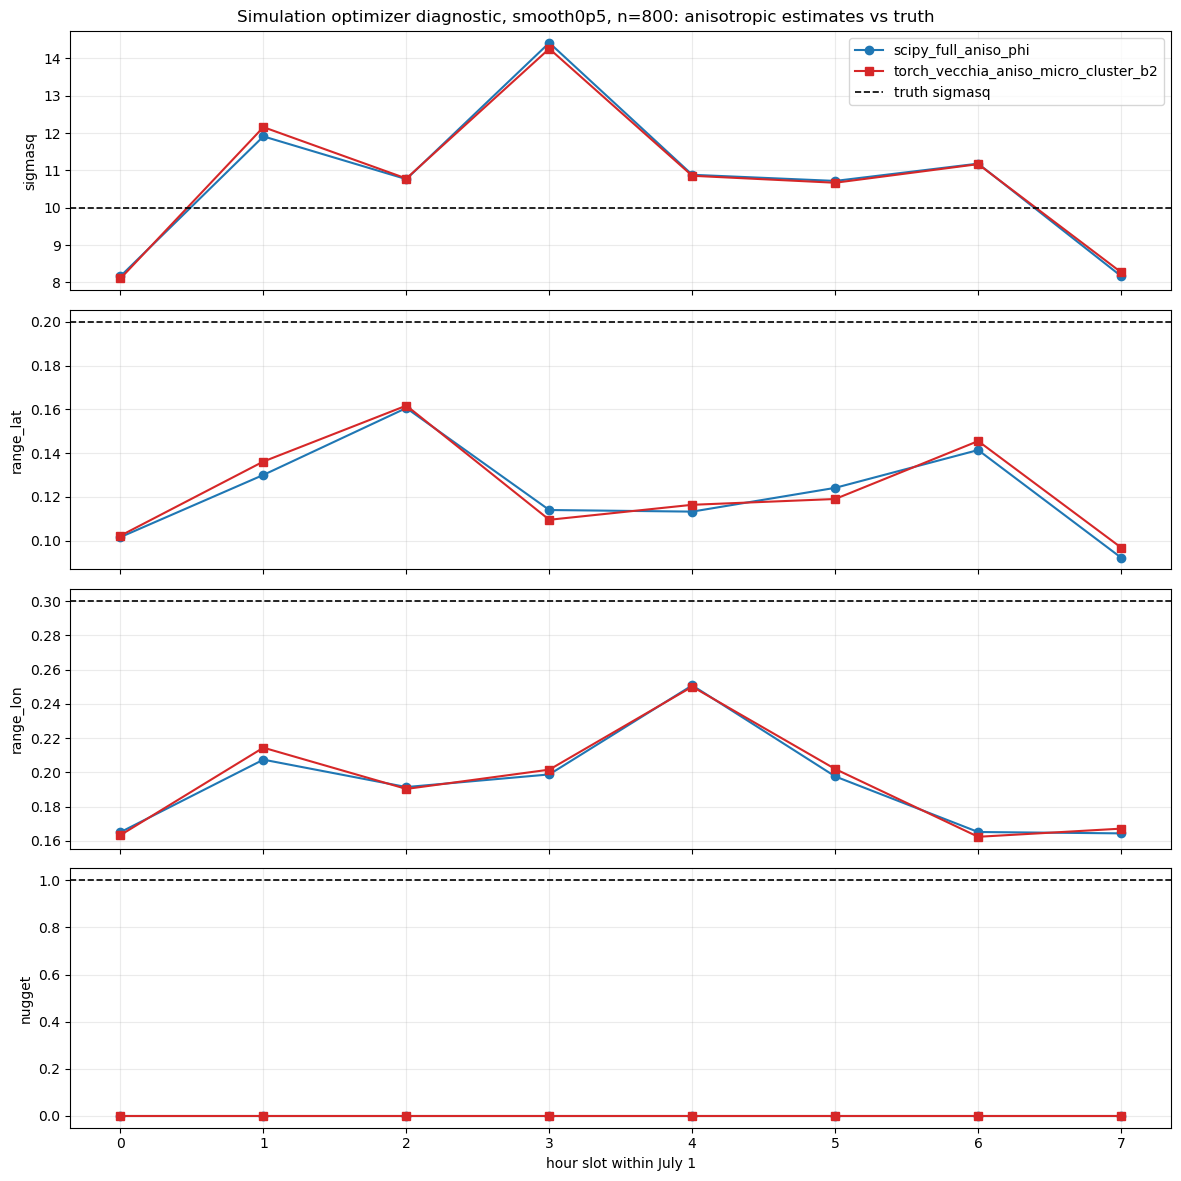

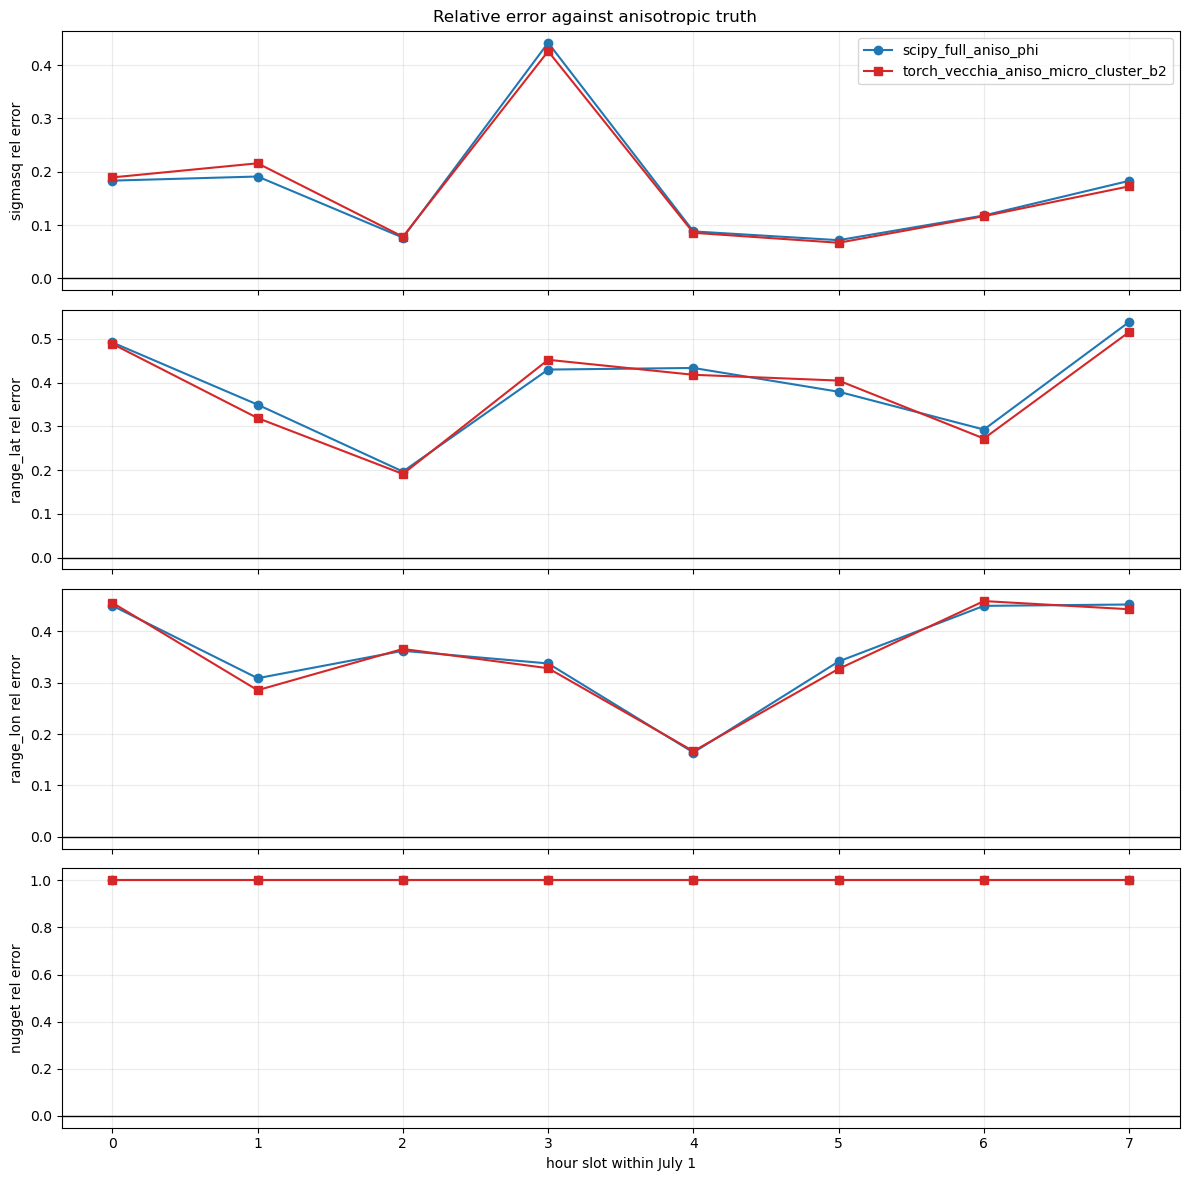

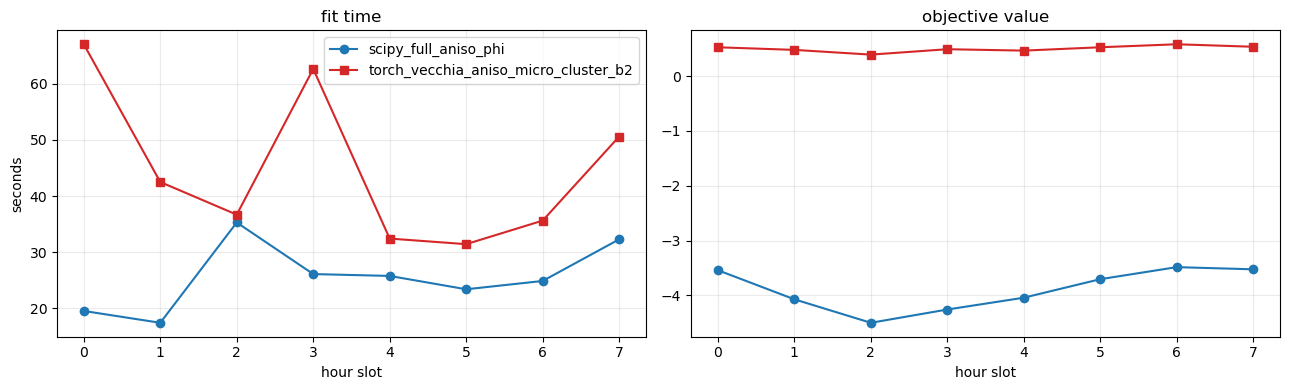

In [9]:

plot_df = results.copy()
colors = {'scipy_full_aniso_phi': '#1f77b4', 'torch_vecchia_aniso_micro_cluster_b2': '#d62728'}
markers = {'scipy_full_aniso_phi': 'o', 'torch_vecchia_aniso_micro_cluster_b2': 's'}
param_cols = ['sigmasq', 'range_lat', 'range_lon', 'nugget']

for method, g in plot_df.groupby('method'):
    finite_count = int(np.isfinite(g[param_cols].to_numpy(dtype=float)).all(axis=1).sum())
    if finite_count == 0:
        print(f'WARNING: {method} has no finite parameter rows, so no line will be drawn. Check the message column above.')

fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)
for ax, p in zip(axes, param_cols):
    for method, g in plot_df.groupby('method'):
        g = g.sort_values('hour_slot')
        y = pd.to_numeric(g[p], errors='coerce')
        finite = np.isfinite(y)
        if finite.any():
            ax.plot(g.loc[finite, 'hour_slot'], y.loc[finite], marker=markers.get(method, 'o'), color=colors.get(method), label=method)
        else:
            ax.plot([], [], marker=markers.get(method, 'o'), color=colors.get(method), label=f'{method} (no finite fits)')
    ax.axhline(float(truth_aniso[p]), color='black', ls='--', lw=1.2, label=f'truth {p}' if p == 'sigmasq' else None)
    ax.set_ylabel(p)
    ax.grid(True, alpha=0.25)
axes[-1].set_xlabel('hour slot within July 1')
axes[0].legend(loc='best')
fig.suptitle(f'Simulation optimizer diagnostic, {SIM_SMOOTH_LABEL}, n={N_FIT}: anisotropic estimates vs truth')
fig.tight_layout()
fig.savefig(OUT_DIR / 'aniso_parameter_estimates_by_hour.png', dpi=180)
plt.show()

fig, axes = plt.subplots(4, 1, figsize=(12, 12), sharex=True)
for ax, p in zip(axes, param_cols):
    col = f'rel_error_{p}'
    for method, g in plot_df.groupby('method'):
        g = g.sort_values('hour_slot')
        y = pd.to_numeric(g[col], errors='coerce')
        finite = np.isfinite(y)
        if finite.any():
            ax.plot(g.loc[finite, 'hour_slot'], y.loc[finite], marker=markers.get(method, 'o'), color=colors.get(method), label=method)
        else:
            ax.plot([], [], marker=markers.get(method, 'o'), color=colors.get(method), label=f'{method} (no finite fits)')
    ax.axhline(0.0, color='black', lw=1)
    ax.set_ylabel(f'{p} rel error')
    ax.grid(True, alpha=0.25)
axes[-1].set_xlabel('hour slot within July 1')
axes[0].legend(loc='best')
fig.suptitle('Relative error against anisotropic truth')
fig.tight_layout()
fig.savefig(OUT_DIR / 'aniso_relative_errors_by_hour.png', dpi=180)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for method, g in plot_df.groupby('method'):
    g = g.sort_values('hour_slot')
    fit_s = pd.to_numeric(g['fit_s'], errors='coerce')
    loss = pd.to_numeric(g['loss'], errors='coerce')
    finite_fit = np.isfinite(fit_s)
    finite_loss = np.isfinite(loss)
    if finite_fit.any():
        axes[0].plot(g.loc[finite_fit, 'hour_slot'], fit_s.loc[finite_fit], marker=markers.get(method, 'o'), color=colors.get(method), label=method)
    else:
        axes[0].plot([], [], marker=markers.get(method, 'o'), color=colors.get(method), label=f'{method} (no finite fits)')
    if finite_loss.any():
        axes[1].plot(g.loc[finite_loss, 'hour_slot'], loss.loc[finite_loss], marker=markers.get(method, 'o'), color=colors.get(method), label=method)
    else:
        axes[1].plot([], [], marker=markers.get(method, 'o'), color=colors.get(method), label=f'{method} (no finite fits)')
axes[0].set_title('fit time')
axes[0].set_ylabel('seconds')
axes[1].set_title('objective value')
for ax in axes:
    ax.set_xlabel('hour slot')
    ax.grid(True, alpha=0.25)
axes[0].legend(loc='best')
fig.tight_layout()
fig.savefig(OUT_DIR / 'aniso_fit_time_and_loss_by_hour.png', dpi=180)
plt.show()



## How to read this diagnostic

- Now both methods report the **same anisotropic parameter vector**: `sigmasq, range_lat, range_lon, nugget`. Both SciPy and torch optimize the production-style `phi1, phi2, phi3, nugget` scale internally and then convert back.
- If **SciPy full GP** is stable across the 8 hours and close to the truth, then `scipy.optimize.minimize` itself is probably doing its job on this likelihood.
- If SciPy repeatedly reports `success=False`, hits bounds, or gives parameters far from truth while torch Vecchia behaves normally, then the dense likelihood optimization setup is suspicious: bounds, starting values, objective scaling, or parameterization.
- If **both** methods move in the same direction away from truth, that is less likely to be a SciPy-only failure. It can come from the comparison setup: fitting each hour independently even though the simulation was generated with space-time covariance, missing pattern, or using only the first `N_FIT` max-min points.
- If only a few hours behave badly, inspect those hour maps and missingness first. Per-hour single-realization MLEs can be noisy even under the correct model.
